## 🚴‍♂️ Data Analysis Report

This project aims to analyze and predict the daily bike rental count based on various environmental and seasonal factors. The dataset used for this analysis is the Bike Sharing Dataset, which contains daily and hourly records of bike rentals between the years 2011 and 2012. It also includes weather and seasonal information such as temperature, humidity, wind speed, and weather conditions.

Bike sharing systems are a modern version of traditional bike rentals where the entire process, from membership to rental and return, is automated. These systems have become increasingly popular due to their convenience and positive impact on urban mobility, the environment, and public health. The data collected from such systems acts as a valuable source for understanding city-wide travel patterns and the influence of external factors like season and weather on bike usage.

The goal of this project is twofold:
1. To perform a complete data analysis to understand how different environmental and seasonal variables affect the number of bikes rented each day.
2. To build a machine learning model capable of accurately predicting the daily bike rental count based on these variables.

The dataset includes several important features such as:
- **Season, Month, and Year** to capture seasonal trends.
- **Temperature, Humidity, and Windspeed** to represent environmental conditions.
- **Workingday, Holiday, and Weather Situation** to reflect human activity and weather impacts.
- **Casual and Registered Users** to understand the composition of total rentals.

Through this project, we aim to identify key patterns and dependencies within the data, visualize important trends, and finally develop a predictive model that can estimate the expected number of daily bike rentals. The analysis includes data cleaning, feature engineering, exploratory data analysis (EDA), model building, hyperparameter tuning, and model evaluation.

By the end of this project, the model will help in understanding how different factors such as weather conditions, seasonality, and holidays influence the demand for bike rentals, which can be beneficial for resource allocation, operational planning, and policy decision-making. 

## Importing Necessary Libraries 

In [1]:
# Importing required libraries/modules 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

## Loading the Dataset 

In [2]:
day_df = pd.read_csv("day.csv")  # Loading dataset from CSV into a pandas DataFrame 
hour_df = pd.read_csv("hour.csv")  # Loading dataset from CSV into a pandas DataFrame 

## Basic Check 

In [3]:
# Showing first few rows for a quick glance at structure 
day_df.head() 

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
hour_df.head() 

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
# Inspecting dtypes and non-null counts 
day_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
hour_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [9]:
# Getting summary statistics to understand numeric distributions 
day_df.describe() 

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [10]:
hour_df.describe() 

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### **Insights from Descriptive Statistics**

#### Day-level Data (`day_df`)

- The dataset contains **731 records**, representing roughly **two years of data (2011–2012)**.  
- The **season, month, and year columns** are properly encoded (`season` ranges from 1–4, `mnth` from 1–12, and `yr` from 0–1).  
- The **average temperature (`temp`)** is around **0.49** (which translates to roughly 15–20°C), indicating that most days were mild and suitable for biking.  
- The **“feeling temperature” (`atemp`)** is quite close to the actual temperature, meaning people mostly experienced the weather as it was — not too humid or windy to cause discomfort.  
- **Humidity (`hum`)** averages around **62%**, pointing to a moderately humid climate. Extremely dry or extremely sticky days are rare.  
- The **average windspeed (`windspeed`)** is about **0.19**, suggesting calm to mildly breezy weather — ideal for biking.  
- The **average total rental count (`cnt`)** is around **4500 bikes per day**, but it varies widely — some days had as few as 22 rentals, while others reached up to 8700.  
- When broken down by user type:
  - **Registered users** rent far more bikes ~3600 than **casual users** ~850, showing that regular commuters form the majority of users.  

Overall the data looks clean and balanced. Most days had pleasant, bike-friendly weather with mild temperatures and light winds. Rentals fluctuate a lot from day to day, likely depending on season, working days, and weather conditions. 


#### Hour-level Data (`hour_df`)

- This dataset contains **17,379 rows**, matching 731 days × 24 hours — confirming it’s an hourly version of the same data.  
- It includes an extra column called **`hr`**, representing the hour of the day (0–23).  
- The **average hourly rental count (`cnt`)** is around **189**, which fits perfectly with the daily average (~24 × 189 ≈ 4500).  
- There’s a wide range in hourly counts, meaning there are clear high and low activity periods (likely morning and evening peaks).  
- The weather-related columns (`temp`, `atemp`, `hum`, `windspeed`) show similar ranges and distributions to the daily data — confirming consistency.  
- No missing values or data quality issues are found. 

In [11]:
# Getting summary statistics to understand categorical distributions 
day_df.describe(include = "O") 

,dteday
count,731
unique,731
top,2011-01-01
freq,1


In [12]:
hour_df.describe(include = "O") 

,dteday
count,17379
unique,731
top,2011-01-01
freq,24


### **Insights from Categorical Summary (`dteday`)**

#### For `day_df`
- The column **`dteday`** contains **731 unique date values**, confirming that it represents **one record per day**.  
- The earliest date recorded is **2011-01-01**, and the dataset continues up to the end of **2012**, covering **two full years**.  
- Each date appears exactly once (`freq = 1`), meaning there are **no duplicate dates** — the daily data is clean and sequential.  


#### For `hour_df`
- The column **`dteday`** also has **731 unique dates**, matching the same date range as the daily dataset.  
- Each date occurs **24 times (`freq = 24`)**, which makes sense because there are 24 hourly records for every single day.  
- The top (most frequent) date shown, **2011-01-01**, simply indicates that it appears 24 times — once per hour. 

### **Final Summary**

Both datasets (`day_df` and `hour_df`) are **clean, consistent, and complete**.  
The daily dataset contains **731 records** (one per day), while the hourly dataset has **17,379 records** (24 per day).  
No missing values or duplicates are found, and all columns are correctly formatted.  

The data covers **two full years (2011–2012)**, with reasonable ranges for temperature, humidity, and windspeed — all indicating normal weather conditions.  
Registered users contribute most of the rentals, while casual users show more variation, likely due to weekends or holidays.  

Since the project aims to **predict total daily rentals**, further **EDA and modeling** will focus on the **daily dataset (`day_df`)**,  
while the hourly dataset (`hour_df`) may be used later for **additional pattern insights**. 

In [13]:
# Convert the 'dteday' column from string (object) to datetime 
day_df["dteday"] = pd.to_datetime(day_df["dteday"]) 

## EDA 

### Univariate Analysis 

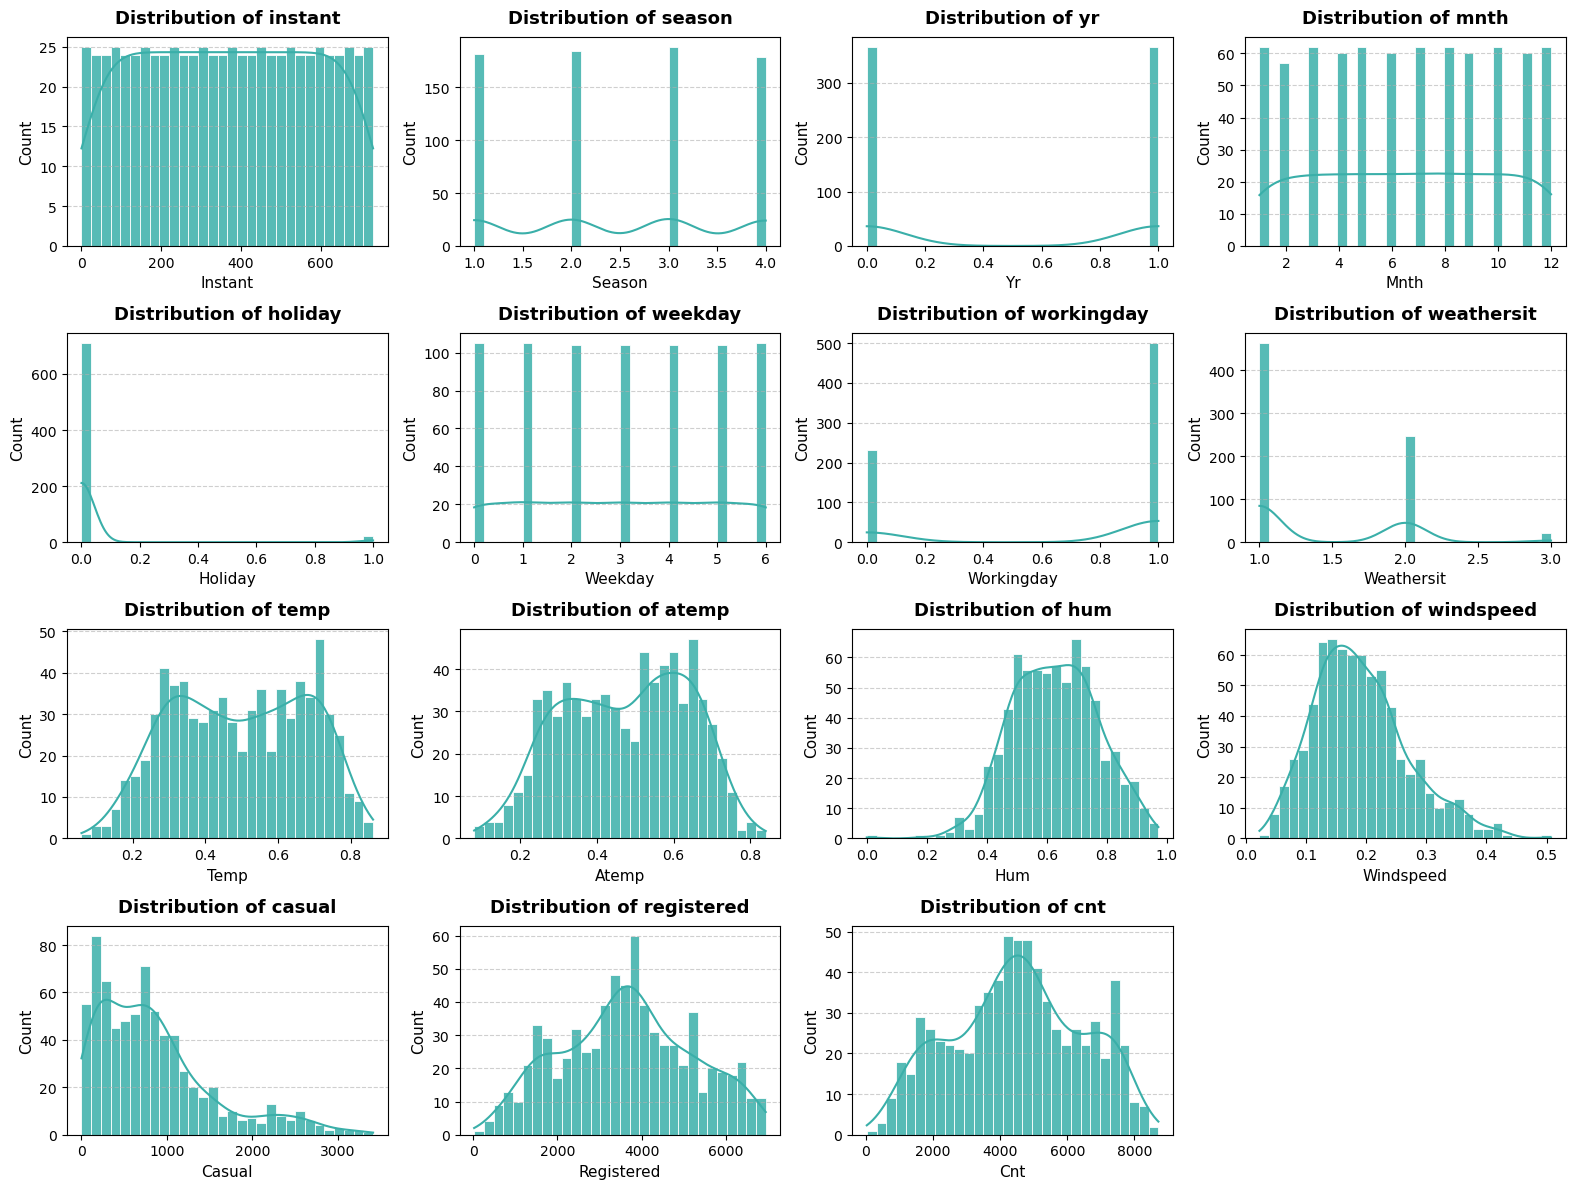

In [14]:
# setting figure size so all histograms are clearly visible
plt.figure(figsize=(16, 12))

# selecting only numerical columns from the day dataset
numerical_cols = day_df.select_dtypes(include=["int", "float"]).columns  

# plotting histograms for each numerical column
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)

    sns.histplot(
        day_df[col],
        kde=True,
        bins=30,
        color="#3AAFA9",        # using teal theme color 
        edgecolor="white",
        alpha=0.85
    )

    # adding title and labels for each plot
    plt.title(f"Distribution of {col}", fontsize=13, fontweight="semibold", pad=10) 
    plt.xlabel(col.replace("_", " ").title(), fontsize=11)
    plt.ylabel("Count", fontsize=11)

    # adding light grid for better readability 
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    
# adjusting layout so plots don’t overlap
plt.tight_layout()
plt.show() 

### Insights 

- The dataset covers **two full years (2011 and 2012)**, with an almost equal number of observations for both years.  
  This ensures there’s no sampling imbalance, allowing us to compare year-over-year changes fairly.

- Each **season** (winter, spring, summer, and fall) and **month** is evenly represented, meaning the data captures **complete seasonal and yearly variation** without any missing time periods.  
  This balance is important for understanding how bike rentals fluctuate across different seasons and months.

- The **holiday** column shows that only a small fraction of days are holidays, while most are regular days.  
  This makes sense in a yearly dataset and indicates that holiday impact, though limited, can still reveal interesting behavioral shifts in rentals.

- The **weekday** distribution is almost uniform, and there are more **working days** than non-working days — consistent with a real-world calendar.  
  This supports analyzing patterns like how commuting (on weekdays) differs from leisure-based rentals (on weekends or holidays).

- In terms of **weather conditions (`weathersit`)**, most days are clear or partly cloudy, while poor weather (rain or snow) is relatively rare.  
  This shows that the dataset mainly captures normal weather conditions, with only a few extreme cases — which helps understand how unfavorable weather affects demand.

- Environmental features like **temperature (`temp`)**, **feeling temperature (`atemp`)**, **humidity (`hum`)**, and **windspeed** are all **naturally distributed**.  
  Temperatures and humidity appear roughly normal, while windspeed distribution is right-skewed, indicating that most days have low wind speeds, while only a few days experience high winds — which is expected in normal weather conditions.” 

- User-related columns show distinct patterns:  
  - **Casual users** have a **right-skewed distribution**, meaning most days have few casual riders and only a few days have high casual activity (likely weekends or good-weather days).  
  - **Registered users** have a **more balanced (near-normal) distribution**, showing a steady base of daily riders — likely commuters.  
  - The **total count (`cnt`)**, which combines both, is also **approximately normal**, showing moderate rentals on most days with a few high-demand spikes.

- Overall, the dataset appears **well-structured and representative**, covering various temporal, environmental, and user-based factors.  
  The distributions look clean, realistic, and without extreme imbalances — making this dataset **reliable for exploring trends and building predictive models**. 

### Bivariate Analysis 

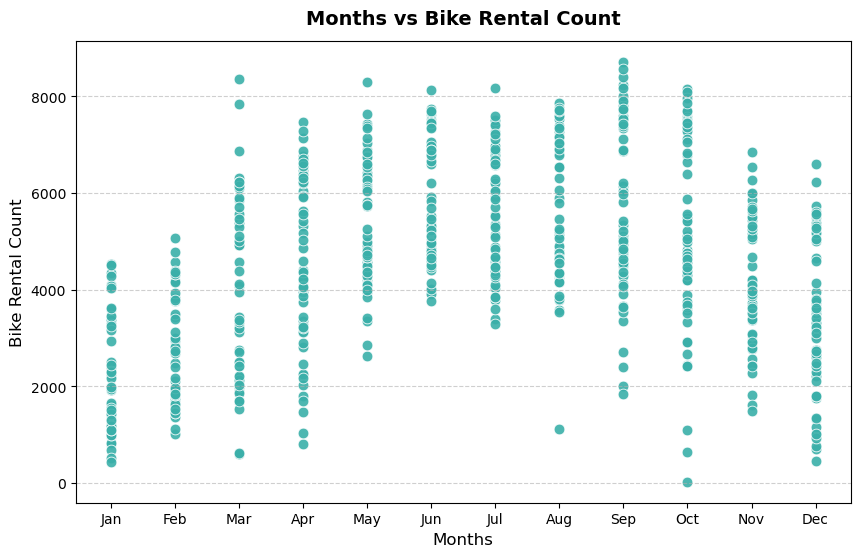

In [15]:
# setting the figure size for the plot
plt.figure(figsize=(10, 6)) 

# scatter plot showing bike rentals across different months
sns.scatterplot(
    x=day_df["mnth"],
    y=day_df["cnt"],
    color="#3AAFA9",        # using teal theme color 
    edgecolor="white",
    s=60,
    alpha=0.9
)

# adding title and axis labels
plt.title("Months vs Bike Rental Count", fontsize=14, fontweight="semibold", pad=12) 
plt.xlabel("Months", fontsize=12)
plt.ylabel("Bike Rental Count", fontsize=12)

# replacing numeric month values with month names
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

# adding light grid for better readability 
plt.grid(axis = "y", linestyle="--", alpha=0.6)

plt.show() 

During the initial months (January and February), the bike rental count is noticeably lower, likely due to the cold winter weather, which discourages outdoor activities.  
Starting from **March**, rentals begin to rise steadily as the weather becomes milder and more favorable for cycling.  
The **summer months (June to August)** show a strong concentration of higher rentals, mostly between **3,500 to 8,000**, indicating peak biking activity during warm and pleasant weather conditions.  
**September** records the **highest rental counts**, with several data points exceeding **8,500**, suggesting continued demand before temperatures start to drop.  
As the **fall season (October)** arrives, rentals slightly decline — possibly because of cooler weather and shorter daylight hours.  
Finally, the **winter months (November and December)** show a sharp decrease in rentals, with counts typically ranging between **500 to 6,000**, reflecting reduced outdoor mobility during colder conditions.  

Overall, the trend indicates a **clear seasonal pattern** — rentals rise from spring to late summer and decline again toward winter. 

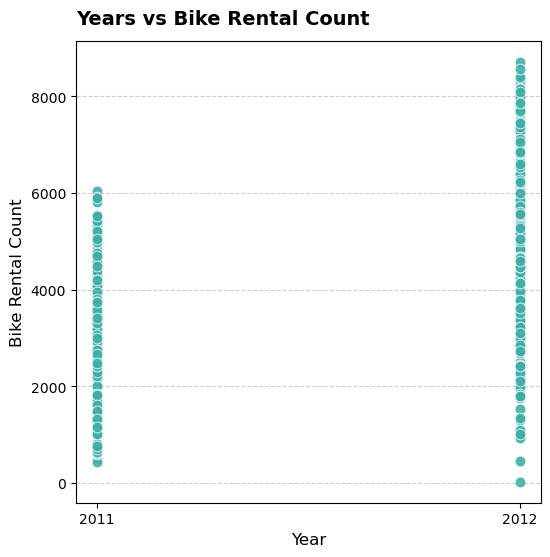

In [16]:
# setting figure size for the plot
plt.figure(figsize=(6, 6)) 

# scatter plot showing total rentals across both years
sns.scatterplot(
    x=day_df["yr"],
    y=day_df["cnt"],
    color="#3AAFA9",      # using teal theme color 
    edgecolor="white",
    s=60,
    alpha=0.9
)

# replacing 0 and 1 with actual year labels
plt.xticks([0, 1], ["2011", "2012"])

# adding title and axis labels
plt.title("Years vs Bike Rental Count", fontsize=14, fontweight="semibold", loc="left", pad=12)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Bike Rental Count", fontsize=12)

# adding light grid for better readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show() 

The bike rental count in **2011** ranged mostly between **500 to 6,000** per day.  
However, in **2012**, the rentals significantly increased, reaching up to around **9,000 per day**.  
This sharp rise in rentals may be due to **growing awareness** and **increased popularity** of the bike rental system among people over time.  
It suggests that more users started adopting the service as it became more familiar and convenient during the second year. 

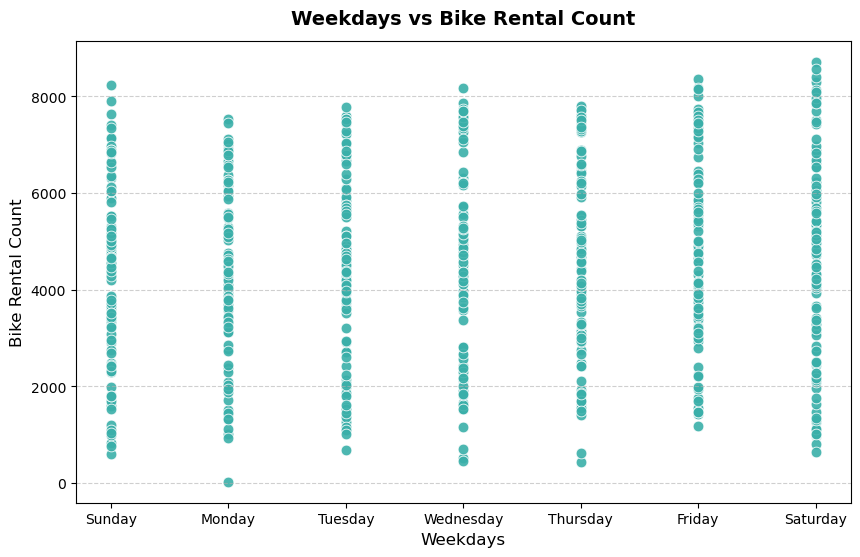

In [17]:
# setting figure size for the plot
plt.figure(figsize=(10, 6)) 

# scatter plot showing total rentals across weekdays
sns.scatterplot(
    x=day_df["weekday"],
    y=day_df["cnt"],
    color="#3AAFA9",        # using teal theme color 
    s=60,
    alpha=0.9
)

# adding title and axis labels
plt.title("Weekdays vs Bike Rental Count", fontsize=14, fontweight="semibold", pad=12)
plt.xlabel("Weekdays", fontsize=12)
plt.ylabel("Bike Rental Count", fontsize=12)

# replacing weekday numbers with actual names
plt.xticks(
    range(7),
    ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
)

# adding light grid for better readability 
plt.grid(axis = "y", linestyle="--", alpha=0.6)

plt.show() 

Bike rentals remain fairly **consistent throughout the week**, with only slight variations between days.  
The dataset represents weekdays from **0 (Sunday)** to **6 (Saturday)**.  
The highest rental counts, often exceeding **8,000**, are seen on **Saturdays**, while other weekdays also show several points above 8,000.  
However, there is **no strong or consistent relationship** between weekday and bike rental count overall.  

This suggests that **bike usage stays steady across the week**, with a small increase during weekends when people likely have more leisure time. 

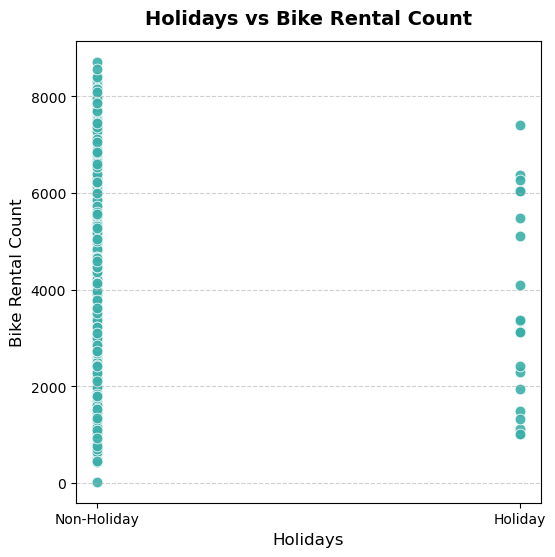

In [18]:
# setting figure size for the plot
plt.figure(figsize=(6, 6)) 

# scatter plot showing total rentals on holidays vs non-holidays
sns.scatterplot(
    x=day_df["holiday"],
    y=day_df["cnt"],
    color="#3AAFA9",         # using teal theme color 
    edgecolor="white",
    s=60,
    alpha=0.9
)

# replacing 0 and 1 with clear labels
plt.xticks([0, 1], ["Non-Holiday", "Holiday"])

# adding title and axis labels
plt.title("Holidays vs Bike Rental Count", fontsize=14, fontweight="semibold", pad=12) 
plt.xlabel("Holidays", fontsize=12)
plt.ylabel("Bike Rental Count", fontsize=12)

# adding light grid for better readability
plt.grid(axis="y", linestyle="--", alpha=0.6) 

plt.show() 

There isn’t a clear relationship between **holidays** and **bike rental count**.  
The dataset contains **very few holidays**, and the rental counts on these days do not show a consistent pattern of increase.  
While most **non-holiday days** have a wide range of rentals, only **a few holidays** show higher counts — around **7,000 rentals or slightly above**.  

This suggests that holidays do not have a major impact on bike rentals, as people may choose other modes of leisure or travel on such days. 

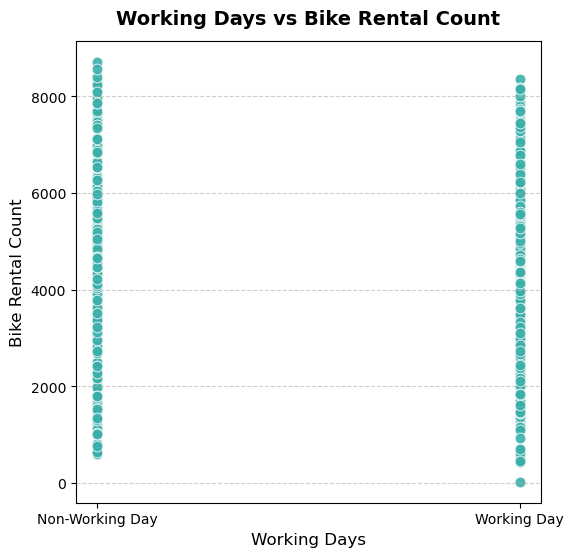

In [19]:
# setting figure size for the plot
plt.figure(figsize=(6, 6)) 

# scatter plot showing total rentals on working vs non-working days
sns.scatterplot(
    x=day_df["workingday"],
    y=day_df["cnt"],
    color="#3AAFA9",        # using teal theme color 
    edgecolor="white",
    s=60,
    alpha=0.9
)

# replacing 0 and 1 with descriptive labels
plt.xticks([0, 1], ["Non-Working Day", "Working Day"])

# adding title and axis labels
plt.title("Working Days vs Bike Rental Count", fontsize=14, fontweight="semibold", pad=12) 
plt.xlabel("Working Days", fontsize=12)
plt.ylabel("Bike Rental Count", fontsize=12)

# adding light grid for better readability
plt.grid(axis="y", linestyle="--", alpha=0.6) 

plt.show() 

There isn’t a significant difference in the number of rentals between **working** and **non-working days**.  
While **non-working days** show slightly higher rental counts, the overall difference is not very large.  
On **working days**, most rentals are made by **registered users**, who likely use bikes for daily commuting.  
In contrast, on **non-working days** (such as weekends), **casual users** tend to rent more bikes, often for leisure or short trips. 

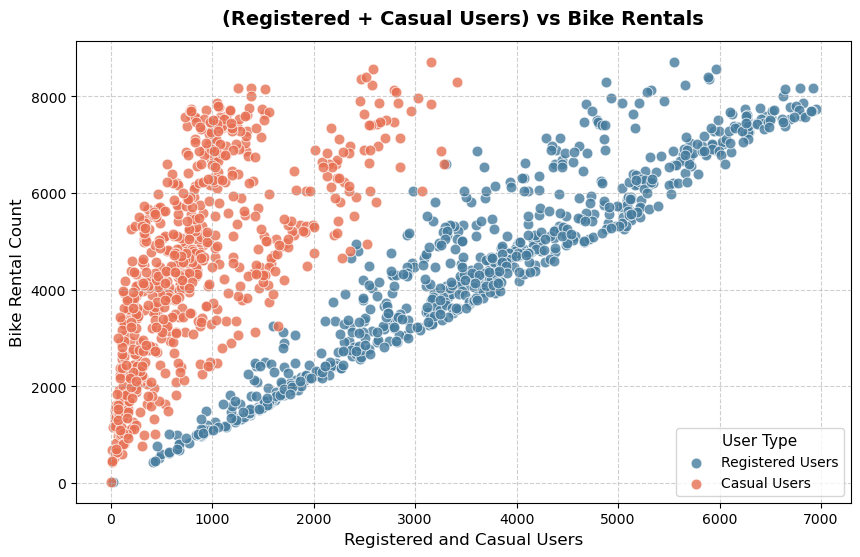

In [20]:
# setting figure size for the plot
plt.figure(figsize=(10, 6))

# scatter plot for registered users
sns.scatterplot(
    x="registered", y="cnt",
    data=day_df, label="Registered Users",
    color="#457B9D", s=60, edgecolor="white", alpha=0.8
)

# scatter plot for casual users
sns.scatterplot(
    x="casual", y="cnt",
    data=day_df, label="Casual Users",
    color="#E76F51", s=60, edgecolor="white", alpha=0.8
)

# adding title and axis labels
plt.title("(Registered + Casual Users) vs Bike Rentals", fontsize=14, fontweight="semibold", pad=12) 
plt.xlabel("Registered and Casual Users", fontsize=12)
plt.ylabel("Bike Rental Count", fontsize=12)

# adding light grid for better readability 
plt.grid(linestyle="--", alpha=0.6) 

# keeping legend simple and clean
plt.legend(title="User Type", title_fontsize=11, fontsize=10) 

plt.show() 

The plot shows a **strong linear relationship** between the number of **registered users** and the total bike rentals.  
As the number of registered users increases, the rental count also rises steeply, indicating that most bike rentals come from this group.  
In contrast, **casual users** show a much **weaker and more scattered distribution**, suggesting less consistent usage.  

This pattern makes sense — **registered users** likely rent bikes regularly for daily commuting, while **casual users** rent bikes occasionally, such as on weekends or holidays for leisure. 

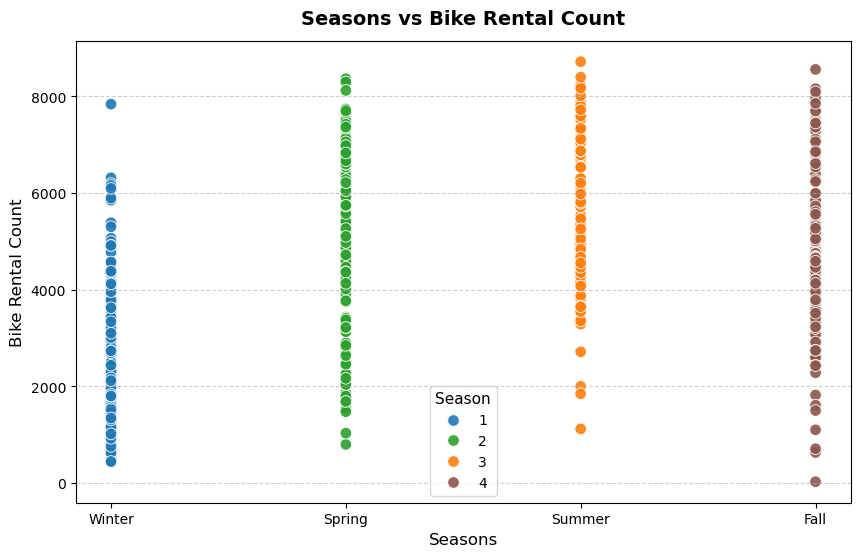

In [21]:
# setting the size of the plot
plt.figure(figsize=(10, 6))

# defining custom colors for each season
season_colors = {
    1: "#1f77b4",  # winter - cool blue tone
    2: "#2ca02c",  # spring - fresh green tone
    3: "#ff7f0e",  # summer - bright orange tone
    4: "#8c564b"   # fall - brown earthy tone
}

# scatter plot showing bike rentals across different seasons
sns.scatterplot(
    x=day_df["season"],
    y=day_df["cnt"],
    hue=day_df["season"],
    palette=season_colors,
    s=70,
    edgecolor="white",
    alpha=0.9
)

# setting x-axis labels to season names
plt.xticks([1, 2, 3, 4], ["Winter", "Spring", "Summer", "Fall"])

# adding title and axis labels
plt.title("Seasons vs Bike Rental Count", fontsize=14, fontweight="semibold", pad=12)
plt.xlabel("Seasons", fontsize=12)
plt.ylabel("Bike Rental Count", fontsize=12)

# adding light grid for better readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

# keeping legend clean and simple
plt.legend(title="Season", title_fontsize=11, fontsize=10)

plt.show() 

The plot shows a clear seasonal pattern in bike rental behavior. During **winter (season 1)**, bike rentals are at their lowest, likely due to cold temperatures and less favorable riding conditions. As the weather improves in **spring (season 2)**, the number of rentals starts increasing steadily. **Summer (season 3)** marks the peak season, with the highest rental counts, as warm and pleasant weather encourages both casual and regular users to ride more frequently. In **fall (season 4)**, the demand remains fairly strong but begins to decline slightly as the temperatures drop again. Overall, this trend suggests that **seasonal changes have a strong influence on bike rental demand**, with people preferring to ride more during warmer, comfortable months compared to colder seasons. 

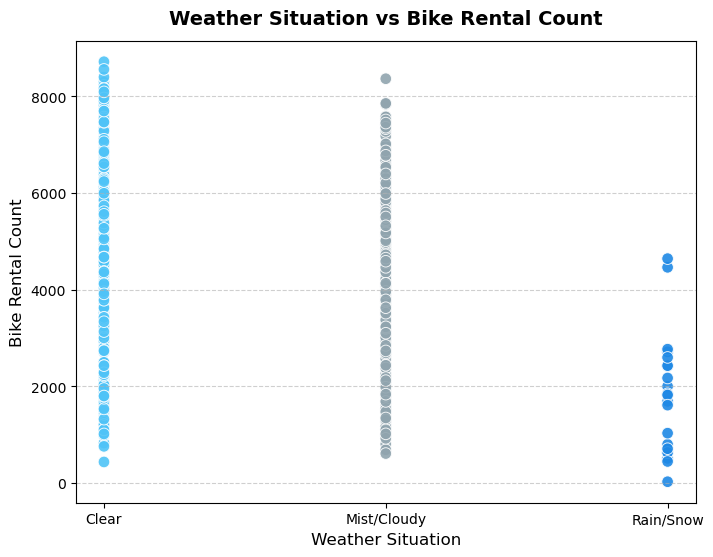

In [22]:
# setting figure size for the plot
plt.figure(figsize=(8, 6)) 

# scatter plot showing bike rentals across different weather conditions
sns.scatterplot(
    x="weathersit",
    y="cnt",
    data=day_df,
    hue="weathersit",
    palette={
        1: "#4FC3F7",  # clear sky blue
        2: "#90A4AE",  # misty gray
        3: "#1E88E5",  # rainy blue
    },
    s=70,
    edgecolor="white",
    alpha=0.9,
    legend=False
)

# replacing numeric weather codes with readable labels
plt.xticks([1, 2, 3], ["Clear", "Mist/Cloudy", "Rain/Snow"]) 

# adding title and axis labels
plt.title("Weather Situation vs Bike Rental Count", fontsize=14, fontweight="semibold", pad=12)
plt.xlabel("Weather Situation", fontsize=12)
plt.ylabel("Bike Rental Count", fontsize=12)

# adding light grid for better readability 
plt.grid(axis="y", linestyle="--", alpha=0.6) 

plt.show() 

Weather conditions have a clear impact on bike rentals.  
During **clear weather**, the number of rentals is the highest, reaching over **8,500** in some cases.  
Rentals slightly decrease during **misty or cloudy** weather but remain moderate.  
However, during **rainy or snowy** conditions, bike rentals drop sharply, as people generally avoid cycling in uncomfortable or unsafe weather.  

This shows that favorable weather encourages more people to rent bikes, while adverse conditions significantly reduce rentals. 

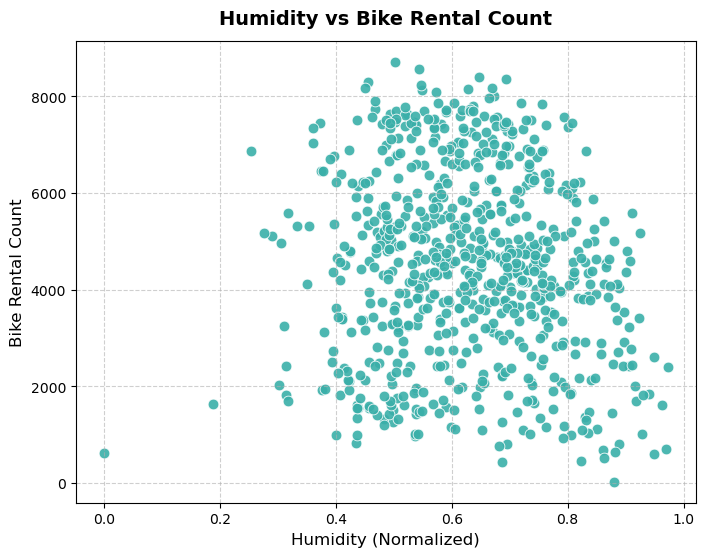

In [23]:
# setting figure size for the plot
plt.figure(figsize=(8, 6)) 

# scatter plot showing relationship between humidity and total rentals
sns.scatterplot(
    x=day_df["hum"],
    y=day_df["cnt"],
    color="#3AAFA9",       # using teal theme color 
    edgecolor="white",
    s=60,
    alpha=0.9
)

# adding title and axis labels
plt.title("Humidity vs Bike Rental Count", fontsize=14, fontweight="semibold", pad=12) 
plt.xlabel("Humidity (Normalized)", fontsize=12)
plt.ylabel("Bike Rental Count", fontsize=12)

# adding light grid for better readability 
plt.grid(axis="both", linestyle="--", alpha=0.6) 

plt.show() 

There is no clear relationship between **humidity** and **bike rental count** when considered alone.  
The data points are spread widely, showing that changes in humidity levels do not strongly affect the number of rentals.  
However, when combined with other factors such as **temperature** or **wind speed**, humidity may provide a clearer understanding of how weather impacts bike rentals. 

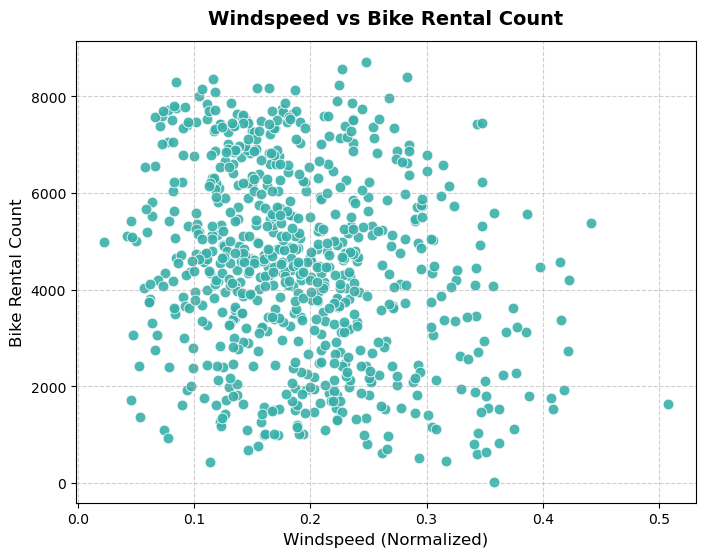

In [24]:
# setting figure size for the plot
plt.figure(figsize=(8, 6)) 

# scatter plot showing relationship between windspeed and total rentals
sns.scatterplot(
    x=day_df["windspeed"],
    y=day_df["cnt"],
    color="#3AAFA9",       # using teal theme color 
    edgecolor="white",
    s=60,
    alpha=0.9
)

# adding title and axis labels
plt.title("Windspeed vs Bike Rental Count", fontsize=14, fontweight="semibold", pad=12) 
plt.xlabel("Windspeed (Normalized)", fontsize=12)
plt.ylabel("Bike Rental Count", fontsize=12)

# adding light grid for better readability 
plt.grid(axis="both", linestyle="--", alpha=0.6) 

plt.show() 

There is no clear relationship between **wind speed** and **bike rental count**.  
The data points are widely scattered, showing that variations in wind speed — whether high or low — do not strongly affect the number of rentals.  
This means that **wind speed alone** is not a strong influencing factor on bike rentals.  
However, when combined with other weather variables such as **humidity, temperature, or weather condition**, it might show a more noticeable impact on rental behavior. 

### Multivariate Analysis 

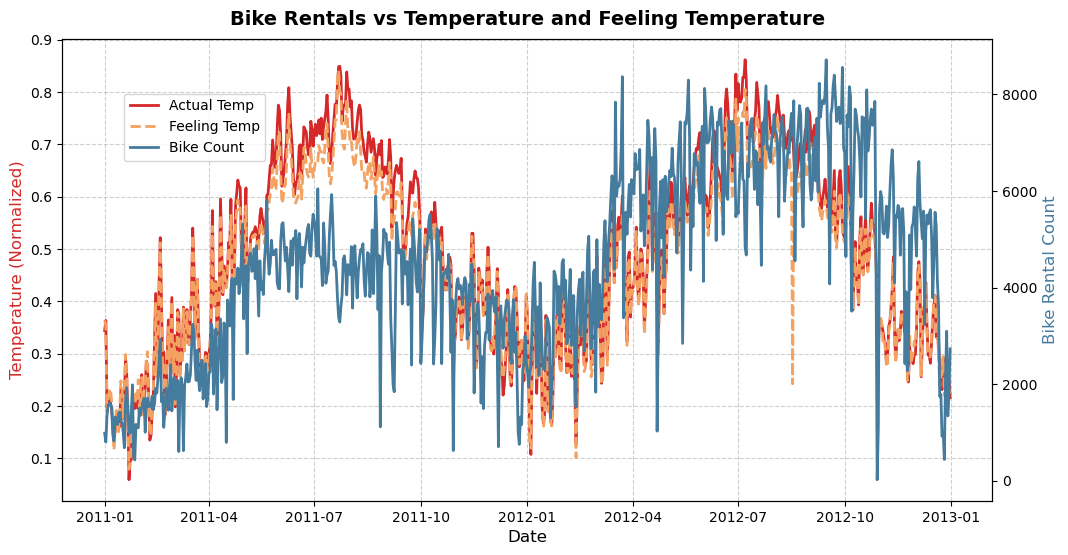

In [25]:
# creating the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# plotting actual and feeling temperature on the left axis
ax1.plot(
    day_df["dteday"], day_df["temp"],
    color="#D62828", linewidth=2, label="Actual Temp"   # bold red line
)
ax1.plot(
    day_df["dteday"], day_df["atemp"],
    color="#F4A261", linewidth=2, linestyle="--", label="Feeling Temp"  # warm orange dashed line
)
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Temperature (Normalized)", color="#D62828", fontsize=12)
ax1.grid(linestyle="--", alpha=0.6)

# adding right axis for bike rental count
ax2 = ax1.twinx()
ax2.plot(
    day_df["dteday"], day_df["cnt"],
    color="#457B9D", linewidth=2, label="Bike Count"   # cool blue line
)
ax2.set_ylabel("Bike Rental Count", color="#457B9D", fontsize=12)

# adding title and legend
plt.title("Bike Rentals vs Temperature and Feeling Temperature", fontsize=14, fontweight="semibold", pad=10) 
fig.legend(fontsize=10, bbox_to_anchor=(0.3, 0.8)) 

plt.show() 

There is a **strong positive relationship** between **temperature** and **bike rentals** over time.  
At the start of the year (during winter), when the temperature is much cooler, the number of rentals is also lower — fewer people prefer cycling in cold weather.  
As the **temperature starts rising from March**, bike rentals also increase steadily.  
During the **summer months (around April to July)**, the rentals remain highest, typically between **4,500 to >5,000 per day**, indicating that warmer weather encourages more people to rent bikes.  

From **August onward**, as temperatures begin to cool down again, the rental count gradually decreases but not drastically.  
By **November and December**, during the colder months, the number of rentals is at its lowest.  
The **year 2012** follows the same overall pattern but shows higher rental counts compared to **2011**, possibly due to **greater awareness** and **increased adoption** of the bike rental system.  

The **actual temperature** and **feeling temperature** almost overlap throughout the year, with only small differences visible during the summer and fall seasons.  
The minor fluctuations in rental counts could be due to **day-to-day weather variations** such as rain or other unfavorable conditions. 

#### Checking for Correlation(Correlation Matrix) 

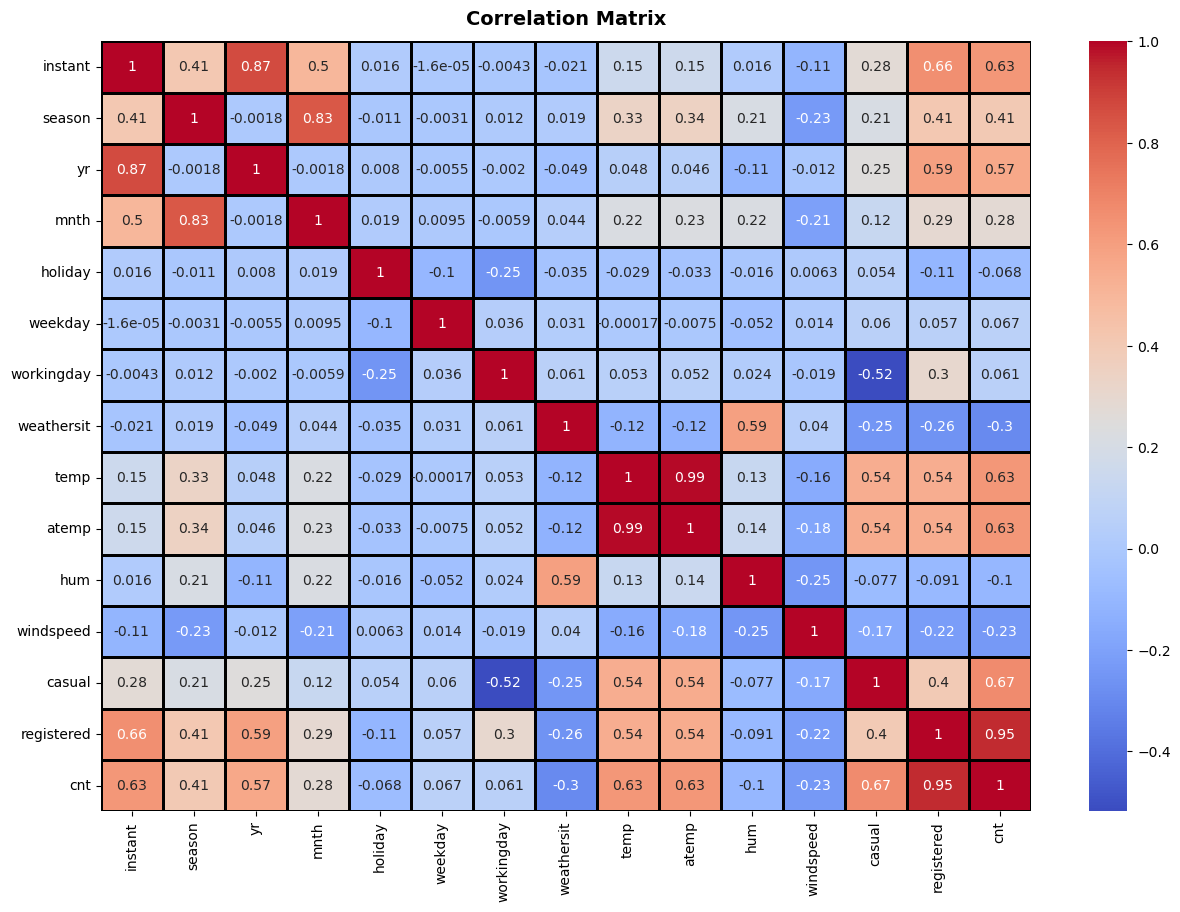

In [26]:
# setting overall figure size for the heatmap
plt.figure(figsize=(15, 10)) 

# selecting only numerical columns for correlation analysis
numerical_cols = day_df.select_dtypes(include=["int", "float"]) 

# plotting heatmap to show correlation between numerical features
sns.heatmap(
    numerical_cols.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=1,
    linecolor="black"
)

# adding title to the heatmap
plt.title("Correlation Matrix", fontsize=14, fontweight="semibold", pad=12)

plt.show() 

The correlation matrix shows how different features relate to each other and to the total bike rental count (**cnt**).

- The **temperature (`temp`)** and **feeling temperature (`atemp`)** have a very strong positive correlation (**0.99**) with each other, which means both behave almost identically — as expected.  
- Both **temperature** and **feeling temperature** also show a strong positive correlation (**~0.63**) with **bike rental count**, indicating that higher temperatures lead to higher bike usage.  
- The **year (`yr`)** variable also has a strong positive correlation (**0.57**) with **bike rental count**, confirming that rentals increased significantly in 2012 compared to 2011.  
- **Casual** and **registered** users are highly correlated with the total count (**0.67** and **0.95**, respectively), as they together make up the total rentals.  
- A moderate positive correlation is observed between **season** and **temperature** (**~0.33–0.34**), since temperature naturally varies across seasons.  
- **Wind speed** shows a weak negative correlation (**-0.23**) with rentals, indicating it has little effect on bike demand when considered alone.  
- **Humidity** and **weather situation** also show weak or negligible correlations with the total count, meaning they don’t strongly influence rentals individually.  

Overall, **temperature**, **season**, and **year** appear to be the most influential features on the number of bike rentals, while weather-related factors like **wind speed** and **humidity** have less impact individually. 

In [27]:
day_df.drop(["instant", "dteday", "registered", "casual", "mnth", "atemp"], axis = 1, inplace = True) # dropping columns that are either irrelevant or highly correlated 

The following columns were dropped from the dataset as they do not contribute meaningfully to the prediction of bike rental count (`cnt`):

- **instant** → This is just an index or record ID and holds no predictive value.  
- **dteday** → Each date value is unique and therefore does not help the model generalize or find patterns.  
- **registered** and **casual** → These directly sum up to the target variable (`cnt = registered + casual`). Keeping them would lead to **data leakage**, making the model learn from information it should not have access to.  
- **mnth** → This is highly correlated with **season** (correlation ≈ 0.83). Both represent similar seasonal effects, so keeping only **season** prevents redundancy.
- **atemp** → The *feeling temperature* is almost identical to the actual temperature (`temp`), showing a **99% correlation**. Keeping both would introduce **multicollinearity**, so only one (`temp`) is retained. 

Dropping these columns helps simplify the dataset, remove multicollinearity, and prevent data leakage, leading to a cleaner and more reliable predictive model. 

## Data Preprocessing 
### Data Cleaning(Checking Duplicate Values) 

In [28]:
day_df.duplicated().sum() # Checking duplicated rows 

0

## Handling Outliers 

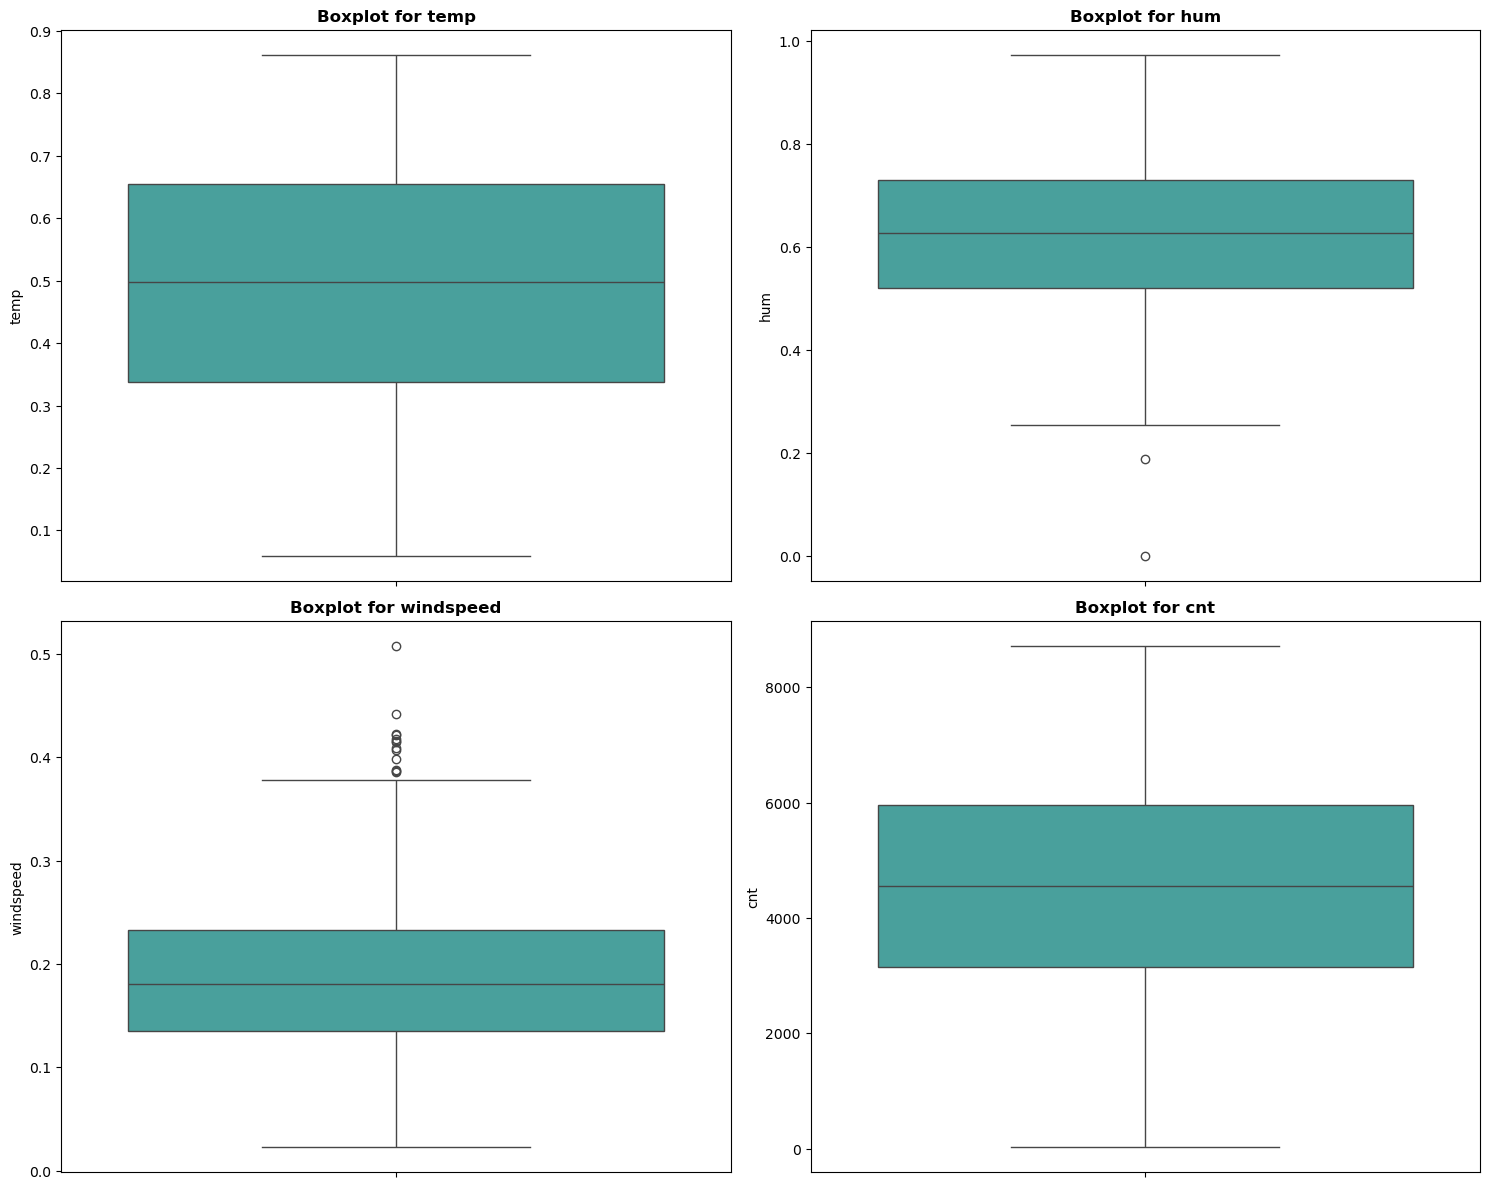

In [29]:
# setting figure size for the boxplots
plt.figure(figsize=(15, 12))

# selecting key numerical features for boxplot analysis
con_num_cols = ['temp', 'hum', 'windspeed', 'cnt'] 

# looping through each feature and plotting its boxplot
for i, col in enumerate(con_num_cols, 1):
    plt.subplot(2, 2, i)

    sns.boxplot(
        y=day_df[col],
        color="#3AAFA9",          # using teal theme color 
        linewidth=1               # clean box edges 
    )

    # adding titles and keeping layout minimal
    plt.title(f"Boxplot for {col}", fontsize=12, fontweight="bold", pad=6)
    plt.xlabel("")                # leaving x-label empty for cleaner look

# adjusting spacing so plots don’t overlap
plt.tight_layout()
plt.show() 

#### Handling outliers through IQR Method 

In [30]:
# selecting continuous numerical columns for outlier treatment
con_num_cols = day_df[['temp', 'hum', 'windspeed', 'cnt']] 

# applying IQR method on selected columns (excluding features where extreme values are expected)
for el in con_num_cols.drop(["temp", "cnt"], axis=1):
    Q1 = day_df[el].quantile(0.25)    # 25th percentile
    Q3 = day_df[el].quantile(0.75)    # 75th percentile
    IQR = Q3 - Q1                     # interquartile range

    # setting lower and upper boundaries using Tukey’s rule (1.5 * IQR)
    lower_boundary = Q1 - 1.5 * IQR
    upper_boundary = Q3 + 1.5 * IQR

    # replacing outliers with median to handle extremes without losing data shape
    day_df.loc[(day_df[el] < lower_boundary) | (day_df[el] > upper_boundary), el] = day_df[el].median() 

##### Outlier Treatment

After checking for outliers, it was found that only **humidity (`hum`)** and **windspeed (`windspeed`)** contained extreme values.  
To handle them, the **Interquartile Range (IQR) method** was applied to detect values lying beyond the lower and upper limits.

The detected outliers were **replaced with the median** of their respective columns instead of being removed. 

## Feature Engineering (New Features) 

In [31]:
# Lag Feature — yesterday’s rental count
day_df['cnt_lag_1'] = day_df['cnt'].shift(1)

# Rolling Mean (7-day) — average of previous week’s rentals
day_df['rolling_mean_7'] = day_df['cnt'].shift(1).rolling(window=7).mean() 

The following new features were added to enhance the predictive power of the model: 
1. **cnt_lag_1** — Represents the number of rentals on the previous day, capturing short-term continuity in demand.
2. **rolling_mean_7** — 7-day moving average of rentals, helping capture weekly patterns and smooth day-to-day fluctuations. 

In [32]:
# Drop first few rows with NaN (due to lag/rolling)
day_df.dropna(inplace=True) 

**Note:** The first few rows contain missing values generated by the lag and rolling features, since these depend on previous days’ data. These NaN values are removed using `dropna()` because keeping them could negatively impact model training and lead to errors or inaccurate predictions. 

## Plotting Correlation Matrix to observe how the newly engineered features relate to the existing ones. 

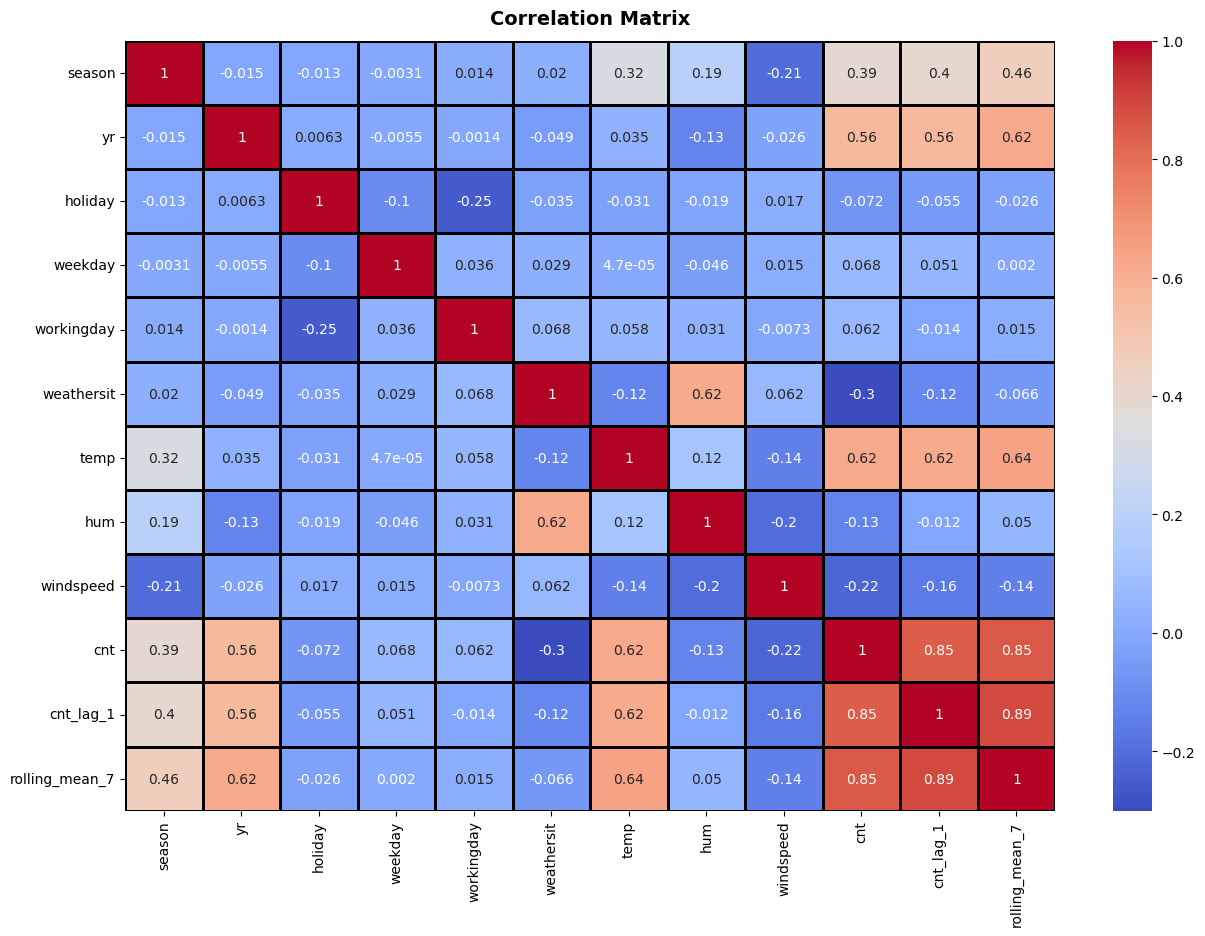

In [33]:
# setting overall figure size for the heatmap
plt.figure(figsize=(15, 10)) 

# selecting only numerical columns for correlation analysis
numerical_cols = day_df.select_dtypes(include=["int", "float"]) 

# plotting heatmap to show correlation between numerical features
sns.heatmap(
    numerical_cols.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=1,
    linecolor="black"
)

# adding title to the heatmap
plt.title("Correlation Matrix", fontsize=14, fontweight="semibold", pad=12)

plt.show() 

After creating new time-based features such as **`cnt_lag_1`** (previous day’s count) and **`rolling_mean_7`** (7-day moving average), I plotted a correlation matrix to understand how these newly engineered features relate to the existing variables and the target variable `cnt`.

From the plot, both **`rolling_mean_7`** and **`cnt_lag_1`** show a very strong positive correlation with `cnt` (around 0.85), which confirms that recent rental activity is one of the strongest indicators of current demand. This makes intuitive sense, as bike rentals usually follow short-term trends influenced by consistent user behavior.

The **`season`** variable also shows a moderate correlation with bike counts, indicating that rentals vary with seasonal patterns (for example, people tend to rent more during warmer months).  
In contrast, **weather-related features** like `temp`, `hum`, and `windspeed` have weaker correlations with `cnt`, and some of them are also correlated with each other — for example, `temp` and `hum` show a noticeable positive correlation (≈ 0.62).  

This analysis helped confirm that the **new temporal features** (`cnt_lag_1` and `rolling_mean_7`) carry more predictive information than individual weather variables, guiding the step — the feature importance analysis — to further evaluate which features truly matter for prediction. 

## Encoding Categorical Variables 

In [34]:
from sklearn.preprocessing import OneHotEncoder # Importing required library/module 

In [35]:
# --- One-Hot Encoding for season, weathersit, and weekday --- 
OHE_enc = OneHotEncoder() 

# Map numeric codes to readable labels
season_map = {1:'Winter',2:'Spring',3:'Summer',4:'Fall'} 
weathersit_map = {1:'Clear',2:'Mist/Cloudy',3:'Rain/Snow'} 
weekday_map = {0:'Sunday',1:'Monday',2:'Tuesday',3:'Wednesday',4:'Thursday',5:'Friday',6:'Saturday'} 

day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weathersit_map)
day_df['weekday'] = day_df['weekday'].map(weekday_map)

# Apply One-Hot Encoding and drop the first dummy to avoid multicollinearity
day_df = pd.get_dummies(day_df, columns=['season','weathersit','weekday'], drop_first=True).astype(int) 

In [36]:
day_df.head()  # Showing first few rows for a quick glance at structure 

,yr,holiday,workingday,temp,hum,windspeed,cnt,cnt_lag_1,rolling_mean_7,season_Spring,season_Summer,season_Winter,weathersit_Mist/Cloudy,weathersit_Rain/Snow,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday
7,0,0,0,0,0,0,959,1510,1344,0,0,1,1,0,0,1,0,0,0,0
8,0,0,0,0,0,0,822,959,1341,0,0,1,0,0,0,0,1,0,0,0
9,0,0,1,0,0,0,1321,822,1344,0,0,1,0,0,1,0,0,0,0,0
10,0,0,1,0,0,0,1263,1321,1340,0,0,1,1,0,0,0,0,0,1,0
11,0,0,1,0,0,0,1162,1263,1297,0,0,1,0,0,0,0,0,0,0,1


The variables `season`, `weathersit`, and `weekday` were encoded using One-Hot Encoding.  
Before encoding, their numeric codes were mapped to readable category names (e.g., `1 → Winter`, `2 → Spring` for season), ensuring that the resulting dummy columns have meaningful names such as `season_Spring`, `weathersit_Mist/Cloudy`, or `weekday_Monday`. 
`drop_first=True` was used to avoid the dummy variable trap, removing one base category from each group. 

## Spliting data into training and testing 

In [37]:
# Split the dataset into features (x) and target variable (y). 
x = day_df.drop("cnt", axis = 1) # x contains all the columns except 'cnt' (the target variable). 
y = day_df["cnt"] # y contains only the 'cnt' column, which is the target variable that the model will predict. 

In [38]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.20) 
# x_train and y_train will be used to train the model, while x_test and y_test will be used for evaluation. 
# The test size is set to 20% of the data (test_size = 0.20), meaning 80% will be used for training. 
# random_state = 42 ensures that the split is reproducible. Using the same random_state will give the same split every time. 

## Scaling 

In [40]:
# Importing required library/module 
from sklearn.preprocessing import MinMaxScaler 

# Selecting continuous features for scaling 
cols_to_scale = ["cnt_lag_1", "rolling_mean_7"] 

# Scaling/normalizing features 
minmax_scaler = MinMaxScaler() 
x_train[cols_to_scale] = minmax_scaler.fit_transform(x_train[cols_to_scale]) 
x_test[cols_to_scale] = minmax_scaler.transform(x_test[cols_to_scale]) 

## Model Creation and Evaluation 

In [41]:
# Importing various regression models from sklearn to apply different machine learning algorithms for regression tasks.

# LinearRegression: A basic linear regression model for predicting continuous variables.
from sklearn.linear_model import LinearRegression 

# DecisionTreeRegressor: A non-linear model that uses a decision tree for regression tasks.
from sklearn.tree import DecisionTreeRegressor

# RandomForestRegressor: An ensemble model that creates multiple decision trees and averages their predictions to reduce overfitting.
from sklearn.ensemble import RandomForestRegressor

# GradientBoostingRegressor: A boosting algorithm that builds trees sequentially, where each tree corrects the errors of the previous one.
from sklearn.ensemble import GradientBoostingRegressor

# SVR (Support Vector Regression): Uses support vector machines for regression tasks, focusing on finding a margin of tolerance for predictions.
from sklearn.svm import SVR

# KNeighborsRegressor: A non-parametric model that makes predictions based on the average of the k-nearest neighbors in the feature space.
from sklearn.neighbors import KNeighborsRegressor 

In [42]:
# Importing regression metrics from sklearn to evaluate model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

### Feature Importance Analysis 

-- Random Forest Regressor --
R2 Score: 0.8344
MAE: 516.1825
MSE: 530721.3334
RMSE: 728.5062


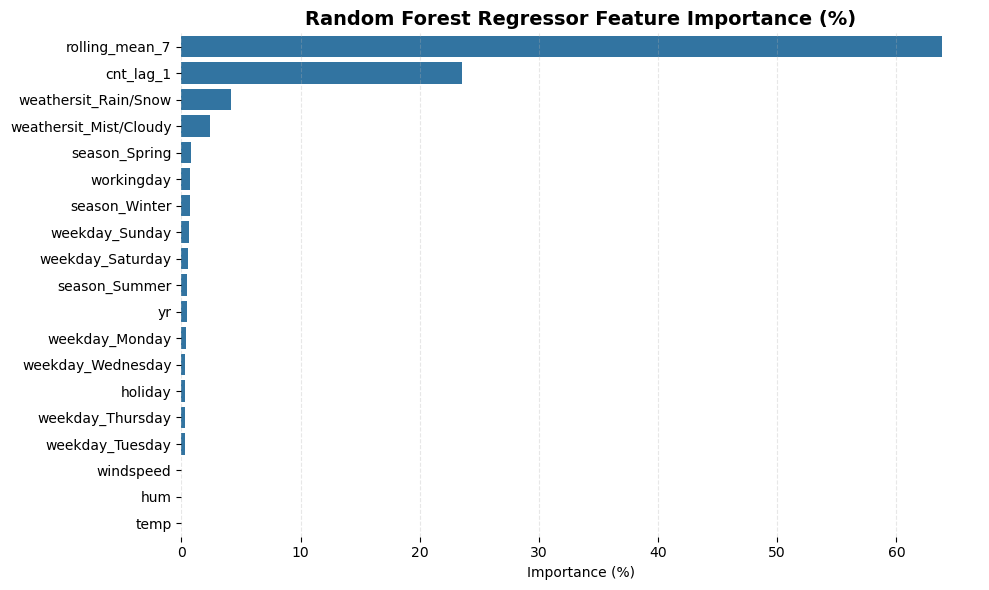


Feature importances (by %):


,Feature,Importance_%
0,rolling_mean_7,63.820996
1,cnt_lag_1,23.572845
2,weathersit_Rain/Snow,4.179137
3,weathersit_Mist/Cloudy,2.399611
4,season_Spring,0.784299
5,workingday,0.740759
6,season_Winter,0.703782
7,weekday_Sunday,0.624094
8,weekday_Saturday,0.517588
9,season_Summer,0.484404


In [43]:
# ---------------- Random Forest Regressor ---------------- #

# Train Random Forest Regressor and report basic metrics + feature importance (gain)
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

# Predictions on the test set
y_pred = rf.predict(x_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print model performance
print("-- Random Forest Regressor --")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

# Extract and normalize feature importances
feature_importances = pd.Series(rf.feature_importances_, index=x_train.columns, dtype=float)
total_importance = feature_importances.sum()
importance_percent = (100 * feature_importances / total_importance) if total_importance > 0 else pd.Series(0.0, index=feature_importances.index)

# Create a sorted DataFrame of feature importances
feature_imp_rf = (
    pd.DataFrame({"Feature": importance_percent.index, "Importance_%": importance_percent.values})
      .sort_values(by="Importance_%", ascending=False)
      .reset_index(drop=True)
)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance_%", y="Feature", data=feature_imp_rf)
plt.title("Random Forest Regressor Feature Importance (%)", fontsize=14, fontweight="bold")
plt.xlabel("Importance (%)")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Display importance table
print("\nFeature importances (by %):")
display(feature_imp_rf) 

-- Gradient Boosting Regressor --
R2 Score: 0.8125
MAE: 566.6790
MSE: 600942.9227
RMSE: 775.2051


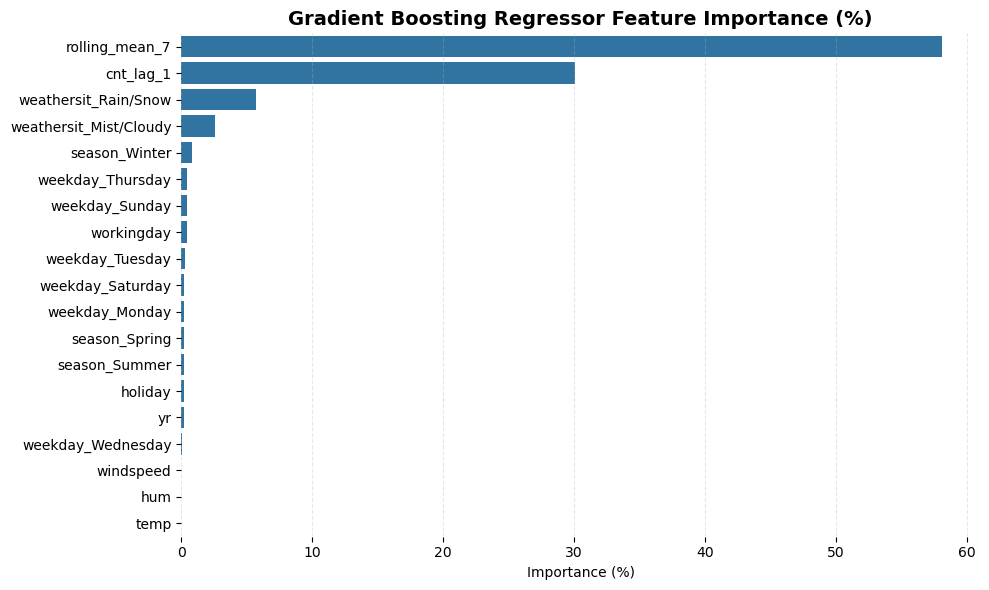


Feature importances (by %):


,Feature,Importance_%
0,rolling_mean_7,58.080156
1,cnt_lag_1,30.094632
2,weathersit_Rain/Snow,5.703492
3,weathersit_Mist/Cloudy,2.587278
4,season_Winter,0.803729
5,weekday_Thursday,0.410007
6,weekday_Sunday,0.407491
7,workingday,0.403569
8,weekday_Tuesday,0.272527
9,weekday_Saturday,0.225575


In [44]:
# ---------------- Gradient Boosting Regressor ---------------- #

# Train Gradient Boosting Regressor and report basic metrics + feature importance (gain) 
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(x_train, y_train)

# Predictions on the test set
y_pred = gbr.predict(x_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print model performance
print("-- Gradient Boosting Regressor --")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

# Extract and normalize feature importances
feature_importances = pd.Series(gbr.feature_importances_, index=x_train.columns, dtype=float)
total_importance = feature_importances.sum()
importance_percent = (100 * feature_importances / total_importance) if total_importance > 0 else pd.Series(0.0, index=feature_importances.index)

# Create a sorted DataFrame of feature importances
feature_imp_gbr = (
    pd.DataFrame({"Feature": importance_percent.index, "Importance_%": importance_percent.values})
      .sort_values(by="Importance_%", ascending=False)
      .reset_index(drop=True)
)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance_%", y="Feature", data=feature_imp_gbr)
plt.title("Gradient Boosting Regressor Feature Importance (%)", fontsize=14, fontweight="bold")
plt.xlabel("Importance (%)")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Display importance table
print("\nFeature importances (by %):")
display(feature_imp_gbr) 

In [45]:
# Columns to drop based on feature importance analysis (low/redundant contribution) 
cols_to_drop = ["windspeed", "hum", "temp"] 

# Remove selected columns from train and test sets
x_train.drop(cols_to_drop, axis=1, inplace=True)
x_test.drop(cols_to_drop, axis=1, inplace=True) 

Before building the predictive models, I examined the feature importance using both **Random Forest Regressor** and **Gradient Boosting Regressor** to identify which variables contribute most to predicting the bike rental count (`cnt`).

From the plots, it is clear that **`rolling_mean_7`** (7-day average count) and **`cnt_lag_1`** (previous day’s count) are the most influential features in both models. This is expected since recent rental activity strongly reflects future demand trends.

Other features such as **weather conditions** (`weathersit_Rain/Snow`, `weathersit_Mist/Cloudy`), **seasonal variables**, and **workingday** also play a role, though their contribution is smaller.

Interestingly, **temperature**, **humidity**, and **windspeed** showed almost **zero importance** in both models. Even though temperature is moderately correlated with bike counts, its predictive influence appears to be already captured through the rolling and lag features. Once the model understands recent rental behavior, these weather-based variables add very little new information.

After this observation, I decided to **drop `temp`, `hum`, and `windspeed`** from the dataset to simplify the model and remove redundant features, keeping only those that truly impact prediction performance. 

### Training Model for Prediction 

In [46]:
# Function to evaluate models on training and testing sets
def evaluate_model(model, x_train, y_train, x_test, y_test):
    # Fit (train) the model on training data
    model.fit(x_train, y_train) 
    
    # Predict on training data
    y_train_pred = model.predict(x_train) 
    
    # Predict on testing data
    y_test_pred = model.predict(x_test) 
    
    # Calculate R² (coefficient of determination) for training set
    r2_train = r2_score(y_train, y_train_pred) 
    
    # Calculate R² for testing set
    r2_test = r2_score(y_test, y_test_pred) 
    
    # Calculate error metrics on test set
    mae = mean_absolute_error(y_test, y_test_pred)        # Mean Absolute Error
    mse = mean_squared_error(y_test, y_test_pred)         # Mean Squared Error
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))  # Root Mean Squared Error
    
    # Return all metrics
    return r2_train, r2_test, mae, mse, rmse 


# Dictionary containing different regression models
models = {
    "Linear Regression": LinearRegression(), 
    "Decision Tree": DecisionTreeRegressor(random_state=42), 
    "Random Forest": RandomForestRegressor(random_state=42), 
    "Gradient Boosting": GradientBoostingRegressor(random_state=42), 
    "Support Vector Regressor": SVR(), 
    "KNeighbors Regressor": KNeighborsRegressor() 
} 


# Dictionary to store results
results = {} 

# Train and evaluate each model
for name, model in models.items():
    # Get evaluation metrics
    r2_train, r2_test, mae, mse, rmse = evaluate_model(model, x_train, y_train, x_test, y_test) 
    
    # Save results in dictionary
    results[name] = {
        "R2_Score_Train": r2_train,
        "R2_Score_Test": r2_test,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    } 


# Convert results dictionary into a DataFrame for easy visualization
results_df = pd.DataFrame(results).T  # .T transposes rows ↔ columns
results_df 

,R2_Score_Train,R2_Score_Test,MAE,MSE,RMSE
Linear Regression,0.836687,0.830687,540.813793,5.426315e+05,736.635249
Decision Tree,1.000000,0.703108,728.993103,9.515076e+05,975.452517
Random Forest,0.970025,0.832803,519.844414,5.358483e+05,732.016610
Gradient Boosting,0.922164,0.812979,564.432223,5.993833e+05,774.198498
Support Vector Regressor,0.021992,-0.005931,1500.105461,3.223910e+06,1795.524931
KNeighbors Regressor,0.807071,0.679813,782.987586,1.026169e+06,1012.999931


## Hyperparameter Tuning to Enhance Model Performance 

In [47]:
from sklearn.model_selection import GridSearchCV # Importing required library/module 

#### For Random Forest Regressor: 

In [48]:
# Import and initialize Random Forest Regressor with a fixed random state for reproducibility
rf_model = RandomForestRegressor(random_state=42) 

# Define the parameter grid for hyperparameter tuning
rf_param_grid = { 
    "n_estimators" : [100, 200, 300, 400, 500],   # Number of trees in the forest
    "max_depth" : [2, 3, 4, 6],                  # Maximum depth of each tree
    "min_samples_split" : [2, 3, 4, 6],        # Minimum samples required to split a node
    "min_samples_leaf" : [2, 3, 4],            # Minimum samples required at a leaf node
    "max_features" : ["sqrt"]     # Number of features considered at each split
} 

# Perform GridSearchCV for hyperparameter tuning
rf_gridsearch_model = GridSearchCV(
    estimator = rf_model, 
    param_grid = rf_param_grid, 
    verbose = 3,                                  # Print progress during search
    refit = True,                                 # Refit model with best parameters after search
    cv = 3,                                       # 3-fold cross-validation
    scoring = "neg_mean_absolute_error",           # Evaluation metric
    n_jobs = -1                                   # Use all CPU cores for faster computation
) 

# Fit the GridSearch model on training data
rf_gridsearch_model.fit(x_train, y_train) 

# Print the best parameters found by GridSearchCV
print("Best params :", rf_gridsearch_model.best_params_) 


# ---- Predictions ----
rf_y_pred_tuned = rf_gridsearch_model.predict(x_test)      # Predictions on test data
rf_y_pred_tuned_train = rf_gridsearch_model.predict(x_train)  # Predictions on train data


# ---- Metrics for tuned Random Forest ----
rf_tuned_metrics = { 
    "R2_Score_Train": r2_score(y_train, rf_y_pred_tuned_train),      # R² score on training data
    "R2_Score_Test": r2_score(y_test, rf_y_pred_tuned),              # R² score on test data
    "MAE": mean_absolute_error(y_test, rf_y_pred_tuned),             # Mean Absolute Error
    "MSE": mean_squared_error(y_test, rf_y_pred_tuned),              # Mean Squared Error
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_y_pred_tuned))     # Root Mean Squared Error
} 

# Convert metrics dictionary into a DataFrame for better readability
rf_tuned_df = pd.DataFrame([rf_tuned_metrics], index=["Random Forest (Tuned)"]) 

# Display results
rf_tuned_df 

Fitting 3 folds for each of 240 candidates, totalling 720 fits


C:\Users\KutbuddinHotel\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best params : {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}


,R2_Score_Train,R2_Score_Test,MAE,MSE,RMSE
Random Forest (Tuned),0.86617,0.822603,546.379457,568539.883678,754.015838


#### For Gradient Boosting Regressor: 

In [49]:
# Importing Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor(random_state=42)

# Defining the parameter grid for GridSearchCV (Hyperparameter tuning)
gb_param_grid = {
    "n_estimators": [100, 150, 200, 300, 400],     # Number of boosting stages (trees)
    "learning_rate": [0.01, 0.02, 0.03, 0.04],     # Shrinks contribution of each tree
    "max_depth": [2, 3, 4, 5],                        # Maximum depth of individual trees
    "min_samples_split": [2, 3, 4],                # Minimum samples required to split a node
    "min_samples_leaf": [2, 3, 4],                 # Minimum samples required at a leaf node
    "max_features": ["sqrt"]               # Number of features considered for best split
}

# Performing GridSearchCV for hyperparameter tuning
# - cv = 3 → 3-fold cross validation
# - scoring = 'neg_mean_squared_error' (because lower MSE = better model)
# - verbose = 3 → detailed logs while training
# - n_jobs = -1 → use all CPU cores for faster training
gb_gridsearch_model = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    verbose=3,
    refit=True,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Fit GridSearchCV model on training data
gb_gridsearch_model.fit(x_train, y_train)

# Print the best set of parameters found by GridSearchCV
print("Best params :", gb_gridsearch_model.best_params_)

# Predict on test and train data using the tuned Gradient Boosting model
gb_y_pred_tuned = gb_gridsearch_model.predict(x_test)
gb_y_pred_tuned_train = gb_gridsearch_model.predict(x_train)

# ---- Metrics for Tuned Gradient Boosting ----
gb_tuned_metrics = {
    "R2_Score_Train": r2_score(y_train, gb_y_pred_tuned_train),   # R² score for training set
    "R2_Score_Test": r2_score(y_test, gb_y_pred_tuned),           # R² score for test set
    "MAE": mean_absolute_error(y_test, gb_y_pred_tuned),          # Mean Absolute Error
    "MSE": mean_squared_error(y_test, gb_y_pred_tuned),           # Mean Squared Error
    "RMSE": np.sqrt(mean_squared_error(y_test, gb_y_pred_tuned))  # Root Mean Squared Error
}

# Store metrics in a DataFrame for better readability
gb_tuned_df = pd.DataFrame([gb_tuned_metrics], index=["Gradient Boosting (Tuned)"])
gb_tuned_df 

Fitting 3 folds for each of 720 candidates, totalling 2160 fits
Best params : {'learning_rate': 0.02, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 400}


,R2_Score_Train,R2_Score_Test,MAE,MSE,RMSE
Gradient Boosting (Tuned),0.891092,0.824757,552.545415,561636.319762,749.423992


In [50]:
# Combine (stack) the previous results DataFrame with the new tuned model results
results_df = pd.concat([results_df, rf_tuned_df, gb_tuned_df]) 

# Display the final results DataFrame
results_df 

,R2_Score_Train,R2_Score_Test,MAE,MSE,RMSE
Linear Regression,0.836687,0.830687,540.813793,5.426315e+05,736.635249
Decision Tree,1.000000,0.703108,728.993103,9.515076e+05,975.452517
Random Forest,0.970025,0.832803,519.844414,5.358483e+05,732.016610
Gradient Boosting,0.922164,0.812979,564.432223,5.993833e+05,774.198498
Support Vector Regressor,0.021992,-0.005931,1500.105461,3.223910e+06,1795.524931
KNeighbors Regressor,0.807071,0.679813,782.987586,1.026169e+06,1012.999931
Random Forest (Tuned),0.866170,0.822603,546.379457,5.685399e+05,754.015838
Gradient Boosting (Tuned),0.891092,0.824757,552.545415,5.616363e+05,749.423992


## 🚴‍♂️ Model Comparison Report

### **Before Hyperparameter Tuning**

In the initial stage, multiple machine learning models were trained to predict the daily bike rental count.  
The models used were **Linear Regression**, **Decision Tree**, **Random Forest**, **Gradient Boosting**, **Support Vector Regressor (SVR)**, and **K-Nearest Neighbors (KNN)**.

From the baseline results, **Linear Regression** performed decently with an R² score of around **0.83** on the test data, showing that it captured most linear patterns.  
However, the dataset clearly contained non-linear relationships, limiting Linear Regression’s predictive power.

The **Decision Tree Regressor** showed signs of strong **overfitting**, with an R² score of **1.0 on training** and only **0.70 on testing**, indicating that it memorized the training data but failed to generalize.

The **Random Forest Regressor** achieved a good balance between bias and variance with a **training R² of 0.97** and **testing R² of 0.83**, along with lower MAE and RMSE compared to other models. This proved that ensemble averaging helped stabilize predictions.  
**Gradient Boosting Regressor** also performed competitively (R² ≈ 0.81), though slightly below Random Forest before tuning.

On the other hand, **SVR** and **KNN** failed to perform well, with poor generalization and higher error values.  
SVR struggled mainly due to scaling sensitivity, and KNN wasn’t ideal for this type of regression data with mixed feature scales.

Overall, before tuning, **Random Forest** gave the most accurate results, followed closely by **Gradient Boosting**.  
However, some overfitting was still visible, so tuning was performed next to improve model generalization and stability.

---

### **After Hyperparameter Tuning**

After applying hyperparameter tuning (using GridSearchCV), both **Random Forest** and **Gradient Boosting** models were fine-tuned for parameters such as the number of estimators, learning rate, and tree depth.

The **Tuned Random Forest Regressor** showed a **clear reduction in overfitting** — the training R² decreased from **0.97 to 0.87**, while the testing R² remained fairly stable (**0.83 → 0.82**).  
However, this improvement in generalization came at a **small cost in prediction accuracy**, as the MAE slightly **increased from 519.84 to 546.38**, and RMSE rose from **732.02 to 754.02**.  
This indicates that while the tuned model became less biased toward the training data (more balanced), its average prediction error on unseen data slightly increased — a classic bias-variance trade-off.

The **Tuned Gradient Boosting Regressor**, however, showed improvement on almost all fronts.  
Its **test R² increased from 0.813 to 0.825**, and both **MAE and RMSE decreased** (MAE ≈ 552, RMSE ≈ 749), meaning the model learned to generalize better without overfitting.  
The tuning effectively optimized the learning rate, depth, and estimator count to achieve smoother learning.

---

### **Final Model Selection**

Based on the final evaluation, both ensemble models — **Random Forest** and **Gradient Boosting** — performed well after tuning.  
However, the **Tuned Gradient Boosting Regressor** achieved the **best balance between bias and variance**, showing strong generalization with the **lowest test RMSE (≈ 749)** and a solid **R² score (≈ 0.825)**.  

Therefore, the **Tuned Gradient Boosting Regressor** is selected as the **best model** for predicting daily bike rental counts.  
It provides consistent predictions, handles non-linear patterns effectively, and shows excellent generalization across various environmental and seasonal conditions influencing bike demand. 

## Challenges Faced and Techniques Used

While working on the Bike Rental Prediction project, several challenges were encountered at different stages of the analysis and model building process. The following points highlight the key issues faced and the techniques used to overcome them.

### 1. Understanding the Dataset
At the beginning, the dataset seemed simple but actually contained many interconnected features such as temperature, humidity, windspeed, and weather conditions. It took some time to understand how these variables affected the total rental count and how features like casual and registered users contributed to it.

**Technique Used:**  
To get a deeper understanding of the data, detailed Exploratory Data Analysis (EDA) was performed. This included univariate, bivariate, and multivariate analysis. 

### 2. Handling Outliers and Data Imbalance
Some numerical features such as humidity and windspeed contained outliers that could influence the model’s learning process. Also, the number of bike rentals varied significantly across months and seasons, leading to an imbalance in the data distribution.

**Technique Used:**  
The Interquartile Range (IQR) method was applied to handle outliers, and necessary feature transformations were made wherever required. Categorical variables such as season, month, and weekday were encoded using one-hot encoding to make them suitable for machine learning models.

### 3. Multicollinearity between Features
Certain features like temperature and apparent temperature, or humidity and windspeed, were found to be correlated with each other. Including all of them together created multicollinearity, which affected the stability and interpretability of linear models.

**Technique Used:**  
Correlation analysis was performed to identify highly correlated variables. To reduce redundancy, correlated features were either dropped or combined. Feature engineering was also applied to create more meaningful variables and remove repetitive information.

### 4. Model Overfitting
While training the models, the Decision Tree and Random Forest (baseline) models showed signs of overfitting. The training accuracy was very high compared to the testing accuracy, which indicated that the model was memorizing the data instead of learning general patterns.

**Technique Used:**  
Hyperparameter tuning was applied using GridSearchCV to control model complexity. After tuning, overfitting was reduced—especially in the Random Forest model where the training R² dropped and the test R² remained stable, indicating better generalization.

### 5. Choosing the Best Model
Since multiple models gave similar R² scores, selecting the best one for production was challenging. While some models had slightly higher accuracy, others performed more consistently across the dataset.

**Technique Used:**  
All models were compared based on R², MAE, and RMSE for both training and testing data. The final decision was made by balancing accuracy and generalization capability. The Tuned Gradient Boosting Regressor was selected as the final model since it provided the best balance between bias and variance, the lowest RMSE, and the most stable performance overall.

### Conclusion
Although several challenges were faced during the project, each step helped improve the model’s performance and understanding of the data. With careful feature engineering, proper outlier treatment, and systematic tuning, a reliable and generalizable model was developed. The project successfully demonstrated how environmental and seasonal conditions affect daily bike rental demand and how machine learning models can effectively predict such real-world patterns. 